In [1]:
import pandas as pd
import numpy as np

# simulate system metrics
np.random.seed(42)

data = {
    "timestamp": pd.date_range(start="2026-01-01", periods=500, freq="T"),
    "cpu_usage": np.random.normal(50, 10, 500),
    "memory_usage": np.random.normal(60, 15, 500),
    "disk_io": np.random.normal(100, 20, 500)
}

df = pd.DataFrame(data)

df.head()

/var/folders/w4/1srpmyh92plgk0g21y1hmdq00000gn/T/ipykernel_28368/1911593707.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  "timestamp": pd.date_range(start="2026-01-01", periods=500, freq="T"),


,timestamp,cpu_usage,memory_usage,disk_io
0,2026-01-01 00:00:00,54.967142,73.892663,127.987109
1,2026-01-01 00:01:00,48.617357,88.641250,118.492674
2,2026-01-01 00:02:00,56.476885,39.021486,101.192607
3,2026-01-01 00:03:00,65.230299,68.444539,87.061264
4,2026-01-01 00:04:00,47.658466,50.240361,113.964466


In [2]:
df.describe()

,timestamp,cpu_usage,memory_usage,disk_io
count,500,500.000000,500.000000,500.000000
mean,2026-01-01 04:09:30,50.068380,60.477392,102.169691
min,2026-01-01 00:00:00,17.587327,19.546700,42.074892
25%,2026-01-01 02:04:45,42.996926,51.070624,87.951408
50%,2026-01-01 04:09:30,50.127971,60.427974,102.396117
75%,2026-01-01 06:14:15,56.367833,69.768634,115.094767
max,2026-01-01 08:19:00,88.527315,99.485731,152.033662
std,NaN,9.812532,14.669958,20.204927


In [3]:
threshold = df["cpu_usage"].mean() + 2 * df["cpu_usage"].std()

anomalies = df[df["cpu_usage"] > threshold]

anomalies

,timestamp,cpu_usage,memory_usage,disk_io
113,2026-01-01 01:53:00,74.632421,43.117664,109.913638
125,2026-01-01 02:05:00,71.904556,52.331765,77.073092
179,2026-01-01 02:59:00,77.201692,79.073326,77.928214
209,2026-01-01 03:29:00,88.527315,85.446846,134.991535
220,2026-01-01 03:40:00,73.146586,64.617027,76.248032
234,2026-01-01 03:54:00,71.439441,75.437335,83.926509
252,2026-01-01 04:12:00,71.221562,45.361901,60.125287
284,2026-01-01 04:44:00,71.330334,68.396857,84.280211
323,2026-01-01 05:23:00,70.923873,54.557422,109.730033
374,2026-01-01 06:14:00,71.531825,59.503095,129.423407


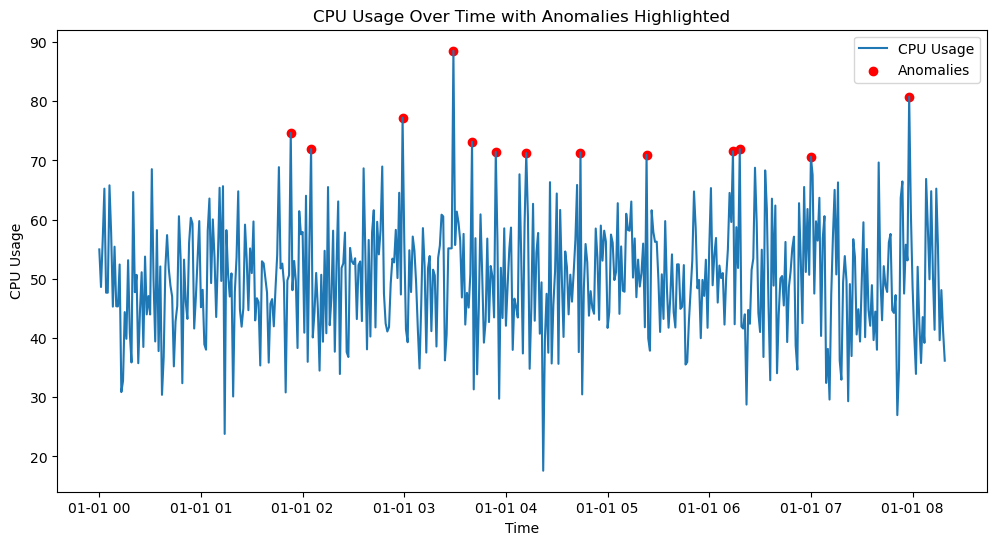

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["timestamp"], df["cpu_usage"], label="CPU Usage")
plt.scatter(anomalies["timestamp"], anomalies["cpu_usage"], color="red", label="Anomalies")

plt.title("CPU Usage Over Time with Anomalies Highlighted")
plt.xlabel("Time")
plt.ylabel("CPU Usage")
plt.legend()

plt.show()

In [5]:
import sqlite3

# create database connection
conn = sqlite3.connect("system_metrics.db")

# store dataframe as SQL table
df.to_sql("metrics", conn, if_exists="replace", index=False)

# run a query to find high CPU events
query = """
SELECT timestamp, cpu_usage
FROM metrics
WHERE cpu_usage > 75
ORDER BY cpu_usage DESC
"""

high_cpu = pd.read_sql(query, conn)

high_cpu

,timestamp,cpu_usage
0,2026-01-01 03:29:00,88.527315
1,2026-01-01 07:58:00,80.788808
2,2026-01-01 02:59:00,77.201692
